In [1]:
from astropy.table import Table
from astropy.io.votable import parse
from astroquery.gaia import Gaia
import astropy.units as u
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
import os
import pandas as pd
import pathlib
import polars as pl
import requests

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [3]:
reportable = pd.read_csv('/Users/mschochet/Downloads/reportable.csv', index_col='Unnamed: 0')
reportable['bp-rp'] = reportable['phot_bp_mean_mag']-reportable['phot_rp_mean_mag']
reportable['frac'] = reportable['sigma']/reportable['period']

In [4]:
cold = reportable[reportable['bp-rp'] >= 0.6]
hot = reportable[reportable['bp-rp'] < 0.6]

oscillators = cold[cold['abs_g_mag'] <= ((2*cold['bp-rp']) - 4)]
nonoscillators = cold[cold['abs_g_mag'] > ((2*cold['bp-rp']) - 4)]

subgiants = nonoscillators[nonoscillators['abs_g_mag'] < ((1.4*nonoscillators['bp-rp'])+2.8)]
ms = nonoscillators[nonoscillators['abs_g_mag'] >= ((1.4*nonoscillators['bp-rp'])+2.8)]

# Main Sequence

## First we'll start with the cool main sequence stars. To do this, we want to plot our predictions in Period-Color space to see if we can reproduce the intermediate period gap. To do this, we have to do a few things
#### 1. Import the santos files so that we have a comparison sample that does possess the intermediate period gap
#### 2. Take the 'Kepler meets Gaia DR3" A1 table from Godoy-Rivera et al. (2025, https://ui.adsabs.harvard.edu/abs/2025A%26A...696A.243G/abstract) to get DR3 IDs so that we can get Gaia G and Rp colors for the Santos stars (need to drop the 2MASS column for import onto ESA Cosmos)
#### 3. Import the combined gaia/GOdoy-Rivera table and cross-match that to the santos catalog to make a list of santos stars with gaia G and Rp magnitudes
#### 4. Plot both populations as well as the period gap as defined in Gordon et al. (2021, https://ui.adsabs.harvard.edu/abs/2021ApJ...913...70G/abstract)

In [5]:
santos1 = Table.read('files/crossmatch/santos1.txt', format="ascii.cds").to_pandas()
santos2 = Table.read('files/crossmatch/santos2.txt', format="ascii.cds").to_pandas()

santostot = pd.concat([santos1, santos2])

In [6]:
url_godoy_rivera = "https://zenodo.org/records/14774100/files/GodoyRivera25_TableA1.csv?download=1"
query_parameters = {"downloadformat": "csv"}
response = requests.get(url_godoy_rivera, params=query_parameters)
with open("godoyrivera.csv", mode="wb") as file:
    file.write(response.content)

In [7]:
keplergaiamatch_before = pd.read_csv('godoyrivera.csv').drop(columns=['2MASS'])
keplergaiamatch_before.to_csv('pregaia_godoyrivera.csv')

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_14948/367891243.py:1: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  keplergaiamatch_before = pd.read_csv('godoyrivera.csv').drop(columns=['2MASS'])


## now is when you would take the saved 'pregaia_godoyrivera.csv' file and import it to the ESA Gaia archive (https://gea.esac.esa.int/archive/) to get color information.

### The ADQL query we used to get necessary information (after importing the table as 'godoyrivera') was:

```
SELECT cross3.dr3_source_id,  gsource.phot_g_mean_mag, gsource.phot_bp_mean_mag, gsource.phot_rp_mean_mag, mine.*, gsource.source_id AS dr2_id1, cross3.dr2_source_id AS dr2_id2
FROM gaiadr3.dr2_neighbourhood AS cross3 
INNER JOIN user_mschoche.godoyrivera AS mine ON mine.dr3_source_id=cross3.dr3_source_id
INNER JOIN gaiadr2.gaia_source AS gsource ON cross3.dr2_source_id=gsource.source_id

```

In [8]:
#keplergaiamatch_final = parse('(#path to saved .vot file from the ESA Cosmos Website#)').get_first_table().to_table().to_pandas()
keplergaiamatch_final = parse('/Users/mschochet/Downloads/1753968185448O-result.vot').get_first_table().to_table().to_pandas().drop_duplicates(subset=['dr3_source_id'])

In [9]:
keplergaiamatch_final.drop(columns=['godoyrivera_oid', 'col1', 'dr3_source_id_2'], inplace=True)

In [10]:
idmatch = Table.read('files/kepler_dr2_1arcsec.fits', format='fits').to_pandas()
idmatch = idmatch.drop_duplicates(subset=['kepid'])
idmatcher = idmatch[['kepid', 'source_id']]
idmatcher = idmatcher.rename(columns={'kepid':'KIC', 'source_id':'dr2_source_id'})
dr2matched = pd.merge(keplergaiamatch_final, idmatcher, on='KIC', how='inner')
del keplergaiamatch_final, idmatcher, keplergaiamatch_before

In [11]:
gaiaids = pl.read_parquet('/Users/mschochet/ASASSN CNN Notebooks/datafiles/allgaiadata.parq').to_pandas().rename(columns={'gaia_id':'dr2_source_id'})

In [12]:
merged = pd.merge(dr2matched, gaiaids, on='dr2_source_id', how='inner')
del gaiaids, dr2matched

In [13]:
combined = pd.merge(santostot, merged, on='KIC', how='inner', suffixes=(None, '_y')).drop(columns=['dr2_id1', 'dr2_id2', 'phot_g_mean_mag_y', 'phot_bp_mean_mag_y', 'phot_rp_mean_mag_y'])
del santostot, merged

In [14]:
ms['g_rp'] = ms['phot_g_mean_mag'] - ms['phot_rp_mean_mag']
combined['g_rp'] = combined['phot_g_mean_mag_x'] - combined['phot_rp_mean_mag_x']

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_14948/3645087314.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ms['g_rp'] = ms['phot_g_mean_mag'] - ms['phot_rp_mean_mag']


In [15]:
validrange = combined[(combined['g_rp']>0.8) & (combined['g_rp']<1.05)]
edgetop = (68.2277*(validrange['g_rp']+0.0653))-(43.7301*((validrange['g_rp']+0.0653)**0.5))
edgebot = (34.0405*(validrange['g_rp']-0.3150))-(2.6183*((validrange['g_rp']-0.3150)**0.5))

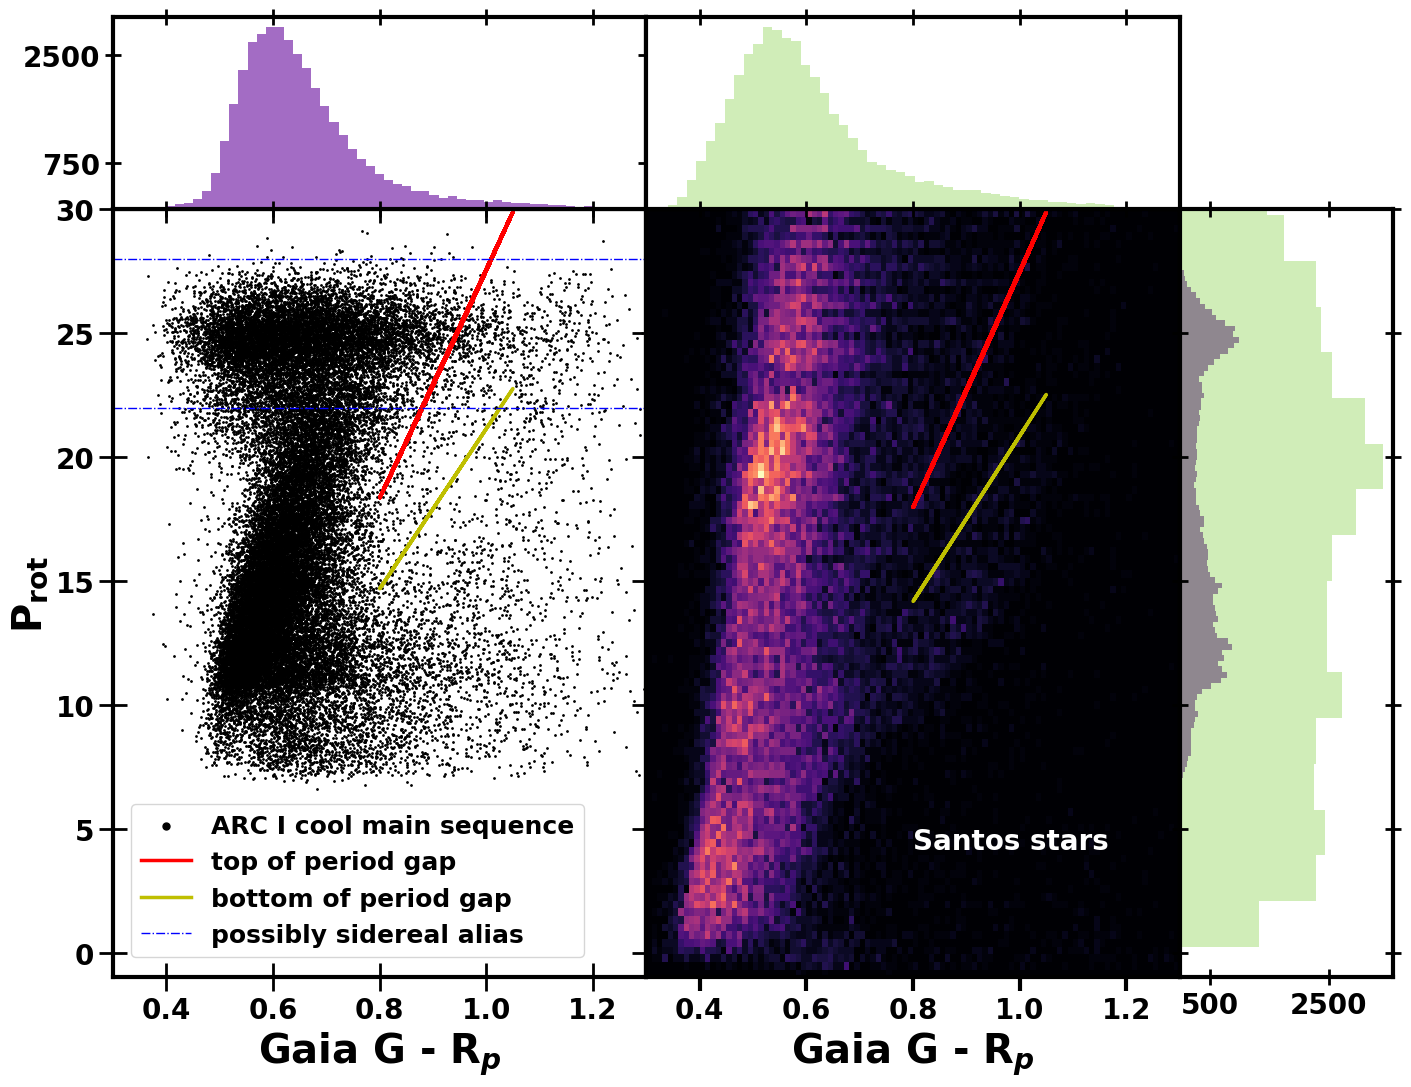

In [23]:
fig = plt.figure(figsize=(16, 12))
prote = r'P$_{\rm{rot}}$'
gs = fig.add_gridspec(2, 3,  width_ratios=(5, 5, 2), height_ratios=(1, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0, hspace=0)
axs = fig.add_subplot(gs[1, 0]) #main our periods plpt
axs2 = fig.add_subplot(gs[1, 1]) #santos periods plot

ax_histx = fig.add_subplot(gs[0, 0], sharex=axs) #us color histogram
ax_histx2 = fig.add_subplot(gs[0, 1], sharex=axs2) #santos color histogram
ax_histy = fig.add_subplot(gs[1, 2], sharey=axs) #combined period histogram

axs.set(xlim = (0.3, 1.3), ylim = (-1, 30), xlabel=f'Gaia G - R$_p$', ylabel=prote)
axs2.set(xlim = (0.3, 1.3), ylim = (-1, 30), xlabel=f'Gaia G - R$_p$')


ax_histx.set_yticks([750, 2500])
ax_histx2.set_yticks([])
ax_histy.set_xticks([500, 2500])

axs.set_xticks([0.4, 0.6, 0.8, 1.0, 1.2])
axs2.set_xticks([0.4, 0.6, 0.8, 1.0, 1.2])
axs2.set_yticks([])


axs.tick_params(which = 'both', direction = 'inout',  top=True, right=True, length=20, width=2)
axs.tick_params(which = 'minor', length = 12, width = 1)

ax_histx.tick_params(axis="x", labelbottom=False)
ax_histx.tick_params(top = True, right = True, length = 12, width = 2, direction = 'inout')

ax_histx2.tick_params(axis="x", labelbottom=False)
ax_histx2.tick_params(top = True, right = True, length = 12, width = 2, direction = 'inout')

ax_histy.tick_params(axis="y", labelleft=False)
ax_histy.tick_params(top = True, right = True, length = 12, width = 2, direction = 'inout')

mingrp = np.nanmin(combined['g_rp'].values)
maxgrp = np.nanmax(combined['g_rp'].values)
minp= np.nanmin(combined['Prot'].values)
maxp = np.nanmax(combined['Prot'].values)

im0 = axs2.hist2d(combined['g_rp'],combined['Prot'],bins=(100, 100),range=[[0.3,1.3],[0,30]], cmap='magma')
im = axs.scatter('g_rp', 'period', c='k', s=1, data=ms, label='ARC I cool main sequence')

ax_histx.hist(ms['g_rp'], bins=100, color='#A36CC4')
ax_histx2.hist(combined['g_rp'], bins=100, color='#64C615', alpha=0.3)

ax_histy.hist(ms['period'], bins=100, color = '#A36CC4', orientation='horizontal')
ax_histy.hist(combined['Prot'], bins=100, color = "#64C615", orientation='horizontal', alpha=0.3)


axs.plot(validrange['g_rp'], edgetop, 'r', linewidth=2.5, label='top of period gap')
axs.plot(validrange['g_rp'], edgebot, 'y', linewidth=2.5, label='bottom of period gap')
axs.plot([0.3, 1.3], [22, 22], 'b-.', linewidth=1, label='possibly sidereal alias')
axs.plot([0.3, 1.3], [28, 28], 'b-.', linewidth=1)

axs2.plot(validrange['g_rp'], edgetop, 'r', linewidth=2.5)
axs2.plot(validrange['g_rp'], edgebot, 'y', linewidth=2.5)

axs.legend(loc='lower left', bbox_to_anchor=(0.01, 0.01), markerscale=5, fontsize=18)
axs2.text(0.8, 5, "Santos stars", c='white')
plt.show()

# Hot stars

### Our hot star sample is the least cooperative of all our subpopulations. Here we will try to demonstrate that for these stars, our predictions are likely spurious. We will do this by trying to compare our network inferred Prot value to a Period derived from photometric observables.

#### If the star we observe has a photometric radius value (radius_val [solar radii]; from Gaia DR2) and a provided spectroscopic rotational broadening (vbroad [km/s]; from Gaia DR3), we can calculate a spectroscopic P/sin(i) as:

$$
\rm{R} \hspace{2pt} \rm{[km]} = \rm{R} \hspace{2pt} \rm{[R\odot]} * 695700
$$

$$
P_{spec} \hspace{2pt} [\frac{\rm{seconds}}{sin(i)}] = \frac{2\pi * \rm{R} \hspace{2pt} \rm{[km]}}{\rm{vbroad}}
$$

$$
P_{spec} \hspace{2pt} [\frac{\rm{days}}{sin(i)}] = P_{spec} \hspace{2pt} [\frac{\rm{seconds}}{sin(i)}] * \frac{1}{86400}

In [24]:
hotgood = hot[(hot['period']>=28) | (hot['period']<=22)]

In [25]:
dr2ids = hotgood['dr2_source_id'].to_list()
len(dr2ids)

1954

In [26]:
from astroquery.gaia import Gaia
Gaia.MAIN_GAIA_TABLE = "gaiadr2.gaia_source" 
query = f"SELECT source_id AS dr2_source_id, radius_percentile_lower, radius_percentile_upper FROM gaiadr2.gaia_source AS gsource WHERE source_id IN ({','.join(map(str, dr2ids))})"

In [27]:
job = Gaia.launch_job(query)
result_table = job.get_results().to_pandas().drop_duplicates(subset='dr2_source_id')

In [28]:
merged = pd.merge(hotgood, result_table, on='dr2_source_id', how='inner')

In [29]:
radii_km = merged['radius_val']*695700
vbroad_km_days = merged['vbroad']*86400
numerator = 2*np.pi*radii_km
denominator = vbroad_km_days
pspec = numerator/denominator
periods = merged['period']
errors_prot = merged['sigma']
errors_pspec_upper = (merged['radius_percentile_upper']*695700)/(merged['vbroad_error']*86400)
errors_pspec_lower = (merged['radius_percentile_lower']*695700)/(merged['vbroad_error']*86400)

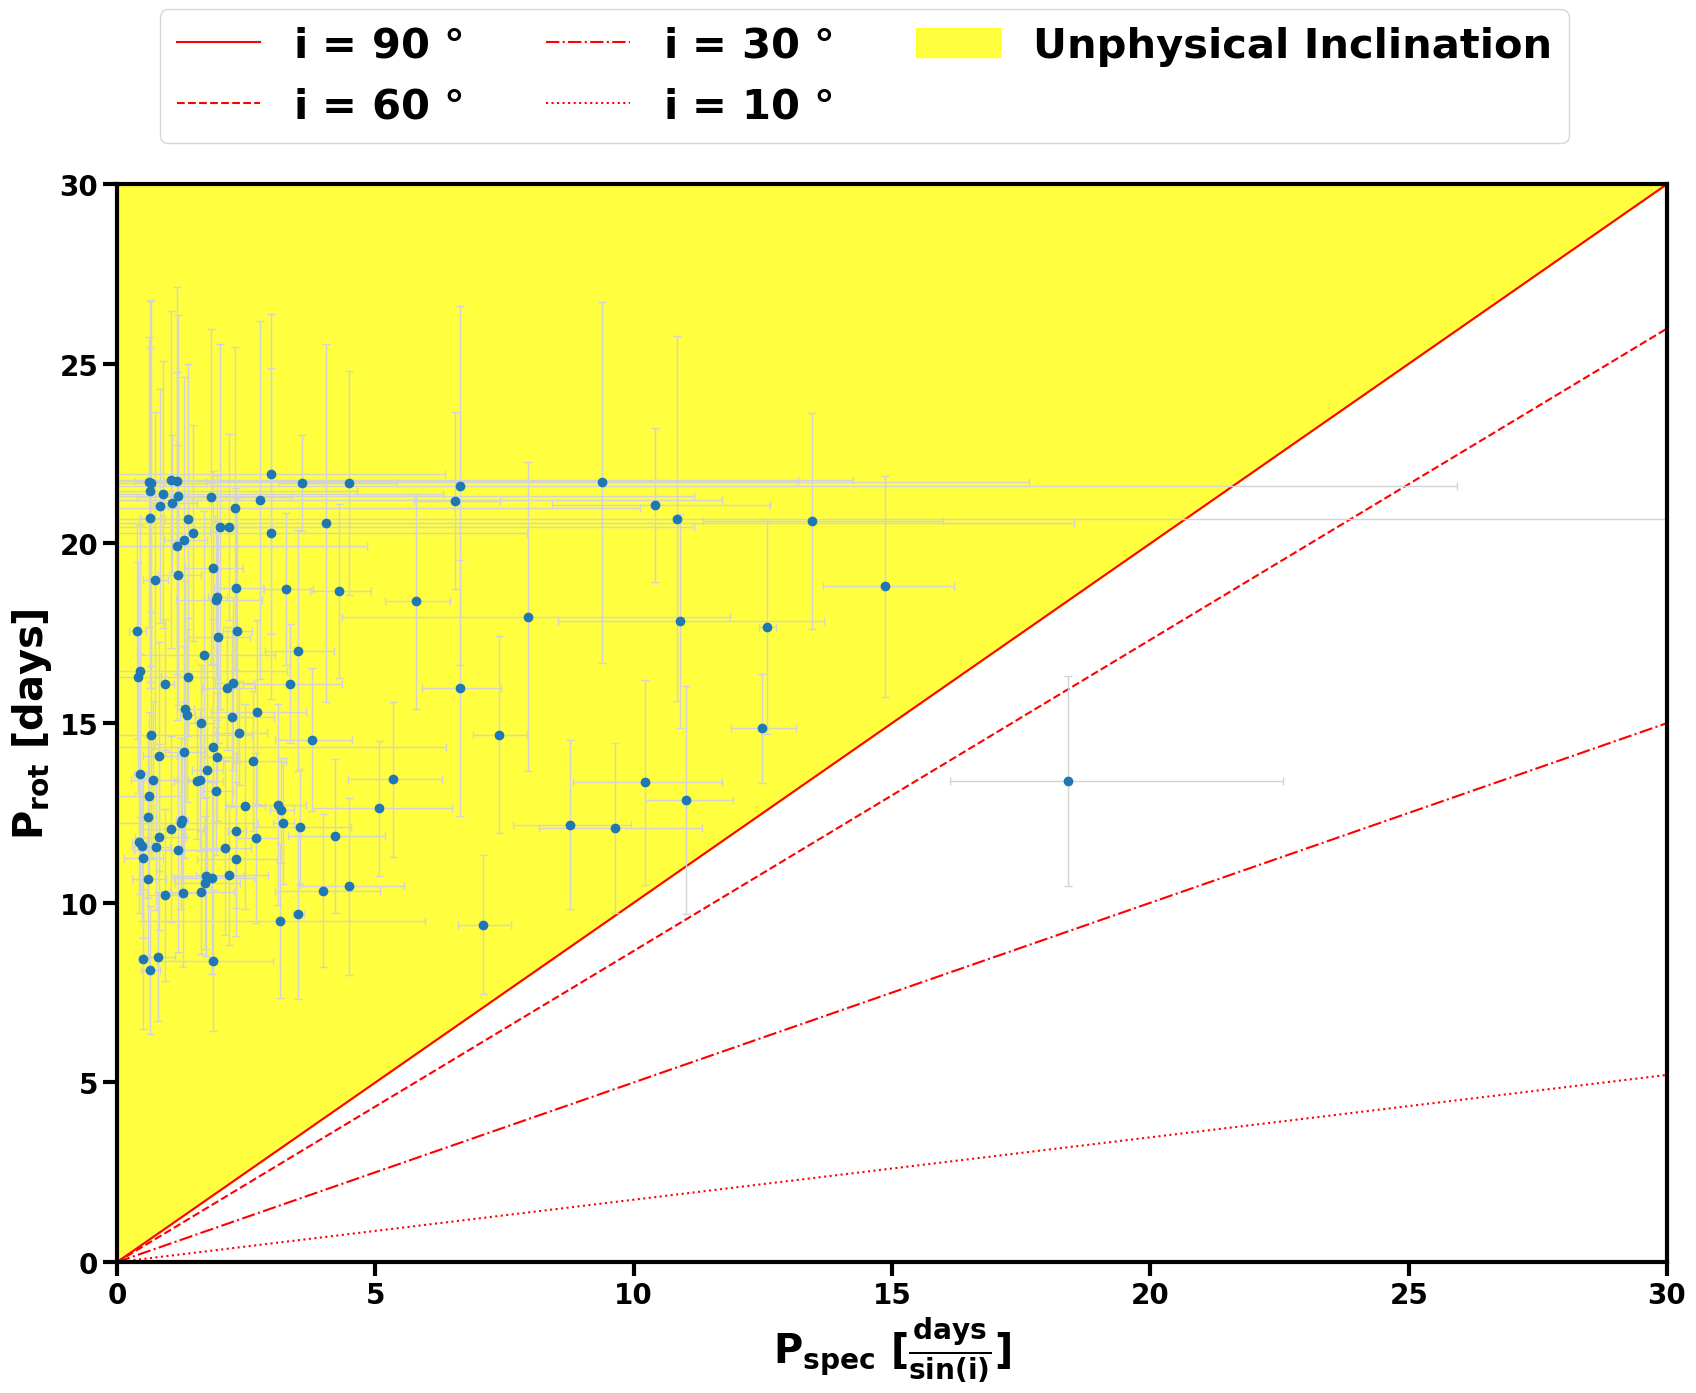

In [35]:
fig, axs = plt.subplots(1, 1, figsize=(20, 14))#, squeeze=True)
axs.set(ylim=[0, 30], xlim=[0, 30], ylabel=r'P$_{\rm{rot}}$ [days]', xlabel=r'P$_{\rm{spec}}$ [$\frac{\rm{days}}{\rm{sin(i)}}$]')
t = axs.plot([0, 30], [0, 30], "r-", label="i = 90 $\degree$")
axs.plot([0, 30], [0, 30*np.sin(60*np.pi*(1/180))], "r--", label="i = 60 $\degree$")
axs.plot([0, 30], [0, 30*np.sin(30*np.pi*(1/180))], "r-.", label="i = 30 $\degree$")
axs.plot([0, 30], [0, 30*np.sin(10*np.pi*(1/180))], "r:", label="i = 10 $\degree$")
axs.fill_between([0, 30], [0, 30], y2=axs.get_ylim()[1], color='yellow', alpha=0.75, label='Unphysical Inclination')
im0 = axs.errorbar(pspec, periods, yerr=errors_prot, xerr=(errors_pspec_lower, errors_pspec_upper), fmt='o',
             ecolor='lightgray', elinewidth=1, capsize=3)
axs.legend(loc='center right', ncols=3, bbox_to_anchor=(0.95, 1.1), fontsize=30)

# Oscillators

### For our oscillator population, we are interested in exploring whether our inferred periods are related to the oscillatory periods of a potential giant star

#### For each star in our sample, we have XGBoost surface gravity (as log(g)) and effective temperature. Using the asteroseismic relation:

$$
\frac{\nu_{\rm{max}}}{\nu_{\rm{max, \odot}}} = f_{\nu_{\rm{max}}} \frac{g}{g_{\odot}} (\frac{T_{eff}}{T_{eff, \odot}})^{-0.5}
$$

#### we can caluclate an approximate $\nu_{max}$ by:

$$
f_{\nu_{\rm{max}}} = 1.01
$$
$$
\frac{T_{eff}}{T_{eff, \odot}} = \frac{T_{eff, XGBoost}}{5777 [K]}
$$
$$
\frac{g}{g_{\odot}} = \frac{10^{log(g)_{XGBoost}}}{10^{4.43811496366}}
$$


#### which put all together gives us:

$$

\nu_{\rm{max}}= 1.01 * (\frac{T_{eff, XGBoost}}{5777 [K]})^{-0.5} * \frac{10^{log(g)_{XGBoost}}}{10^{4.43811496366}} * 86400
$$
$$
\nu_{\rm{max, \odot}} \approx 3090 \rm{MHz}
$$

#### Such that our x axis is graphed as:

$$

\frac{1}{\frac{\nu_{\rm{max}}}{\nu_{\rm{max, \odot}}}} [days]
$$

In [ ]:
unitstable = Table.from_pandas(oscillators)
unitstable['logg_xgboost'].unit = u.Dex
unitstable['teff_xgboost'].unit = u.K

loggs = unitstable['logg_xgboost']
unitstable['logg_xgboost'].unit = u.Dex
unitstable['logg_xgboost'].unit = u.Dex

TypeError: <class 'astropy.units.function.logarithmic.Dex'> can not be converted to a Unit

In [171]:
u.MuHz = u.Hz*1000000

In [ ]:
loggs = unitstable['logg_xgboost']

TypeError: unsupported operand type(s) for *: 'float' and 'type'

In [ ]:
g = (10**())/(10**(4.4*u.Dex)) 
teff = (oscillators['teff_xgboost']*u.K/5777*u.K)**(-1/2)

oscillators['nu_muhz'] = ((g * teff * 3090*u.MuHz))
oscillators['nu_hz'] = 1000000
oscillators['nu_s'] = 1/oscillators['nu_hz']
oscillators['nu_days'] = oscillators['nu_s']/86400

TypeError: unsupported operand type(s) for *: 'numpy.ndarray' and 'type'

In [173]:
muhz = oscillators['nu_muhz']#.to(u.days)
muhz

0          0.406796
1          0.811074
2         12.083860
3          0.594257
5          0.590266
            ...    
208245          NaN
208248     1.602279
208251     0.324057
208252     0.744973
208253     0.660429
Name: nu_muhz, Length: 118138, dtype: float64

In [43]:
kbonuszc = Table.read('files/crossmatch/claytorkbonus.txt', format="ascii.cds").to_pandas()
kbonuszc['dr3_source_id'] = kbonuszc['GaiaDR3'].map(lambda x: x.lstrip('Gaia DR3'))
kbonuszc = kbonuszc.drop('GaiaDR3', axis=1)
kbonuszc['abs_g'] = (kbonuszc['phot_g_mean_mag']+5-(5*np.log10(1000/kbonuszc['plx']))).replace([np.inf, -np.inf], np.nan)
kbonuszc['dr3_source_id'] = kbonuszc['dr3_source_id'].fillna(0).astype(np.int64)

/Users/mschochet/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [44]:
apokascurl = 'https://content.cld.iop.org/journals/0067-0049/276/2/69/revision1/apjsad9feft4_mrt.txt'
query_parameters = {"downloadformat": "txt"}
response = requests.get(apokascurl, params=query_parameters)
with open("apokasc.txt", mode="wb") as file:
    file.write(response.content)
apokasc = Table.read("apokasc.txt", format="ascii.cds").to_pandas()

In [45]:
mergedkbonus_apokasc = pd.merge(kbonuszc, apokasc, on='KIC', how='inner')
mergedus_apokasc = pd.merge(apokasc, oscillators, on='KIC', how='inner')
kbonus_apokasc_us =  pd.merge(mergedus_apokasc, kbonuszc, on='KIC', how='inner')

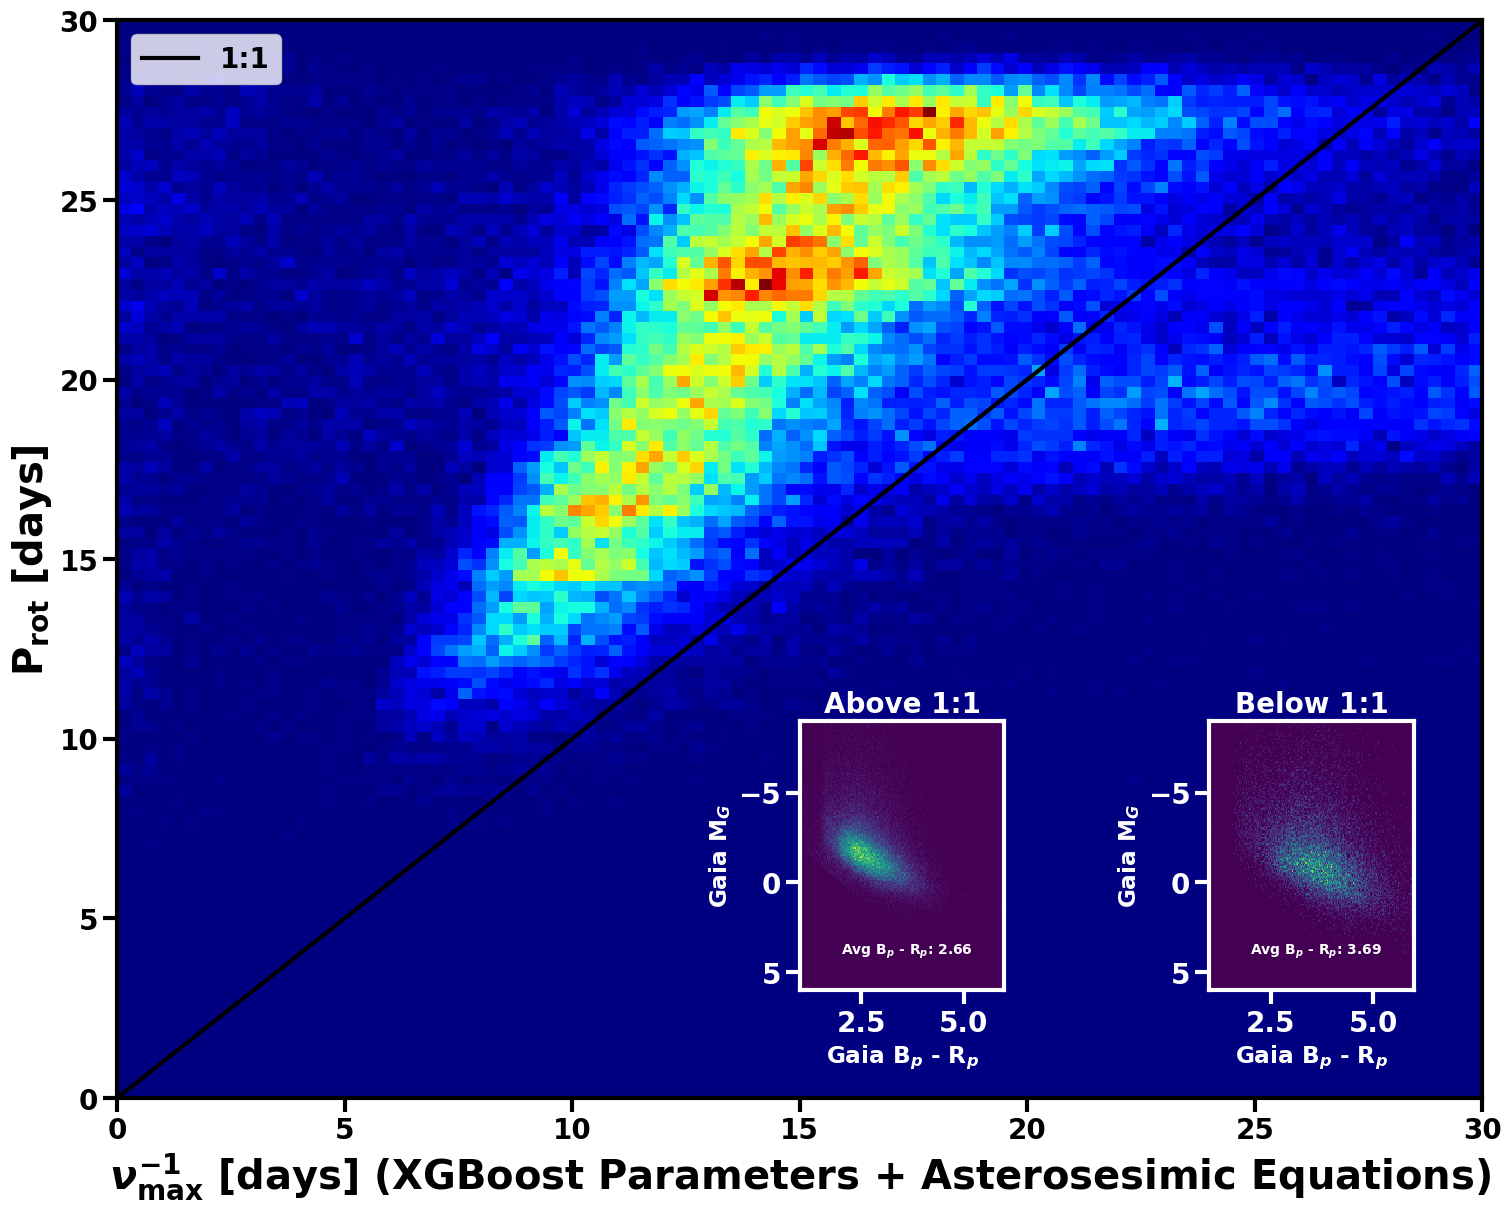

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(15, 12), layout='constrained')
cm = plt.colormaps.get_cmap('Spectral')
axs.set(xlim=(0, 30), ylim=(0, 30), ylabel=r'P$_{\rm{rot}}$ [days]', xlabel=r'$\nu_{\rm{max}}^{-1}$ [days] (XGBoost Parameters + Asteroseismic Equations)')

im = axs.hist2d('nu_days', 'period', data=oscillators, bins=(100, 100), range=([0, 30], [0, 30]), cmap=plt.cm.jet)

axs.plot([0, 30], [0, 30], "k", label="1:1", linewidth=3)

oscillators_good = oscillators[oscillators['period'] >=oscillators['nu_days']]
oscillators_bad = oscillators[oscillators['period'] <oscillators['nu_days']]

axin1 = axs.inset_axes([0.5, 0.1, 0.15, 0.25])
axin2 = axs.inset_axes([0.8, 0.1, 0.15, 0.25])

cmap = plt.cm.viridis_r

axin1.set_xlabel('Gaia B$_p$ - R$_p$', fontsize='small', color='white')
axin1.set_ylabel(f'Gaia M$_G$', fontsize='small', color='white')
axin2.set_xlabel('Gaia B$_p$ - R$_p$', fontsize='small', color='white')
axin2.set_ylabel(f'Gaia M$_G$', fontsize='small', color='white')

axin1.hist2d('bp-rp', 'abs_g_mag',  data= oscillators_good,  bins=(200, 200), range=([1, 6], [-9, 6]), cmap=plt.cm.viridis)
axin2.hist2d('bp-rp', 'abs_g_mag',  data= oscillators_bad, bins=(200, 200), range=([1, 6], [-9, 6]), cmap=plt.cm.viridis)
axin1.invert_yaxis() 
axin2.invert_yaxis() 
axin1.set_title('Above 1:1', weight='bold', fontsize=20, color='white')
axin2.set_title('Below 1:1', weight='bold', fontsize=20, color='white')

for ax in [axin1, axin2]:
    ax.tick_params(color='white', labelcolor='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')

axin1.text(2, 4, f"Avg B$_p$ - R$_p$: {'%.2f' % np.median(oscillators_good['bp-rp'])}", fontsize=10, color='white')
axin2.text(2, 4, f"Avg B$_p$ - R$_p$: {'%.2f' % np.median(oscillators_bad['bp-rp'])}", fontsize=10, color='white')
plt.legend(facecolor='white', loc='upper left')
plt.show()

In [63]:
apokasc_muhz = mergedus_apokasc['Numax']
apokasc_hz = apokasc_muhz/1000000
apokasc_per_s = 1/apokasc_hz
apokasc_per_d = apokasc_per_s/86400

In [86]:
diff = np.abs((apokasc_per_d - mergedus_apokasc['nu_days']))/apokasc_per_d

In [ ]:
normed = colors.Normalize(vmin=np.min(diff), vmax=np.max(d))


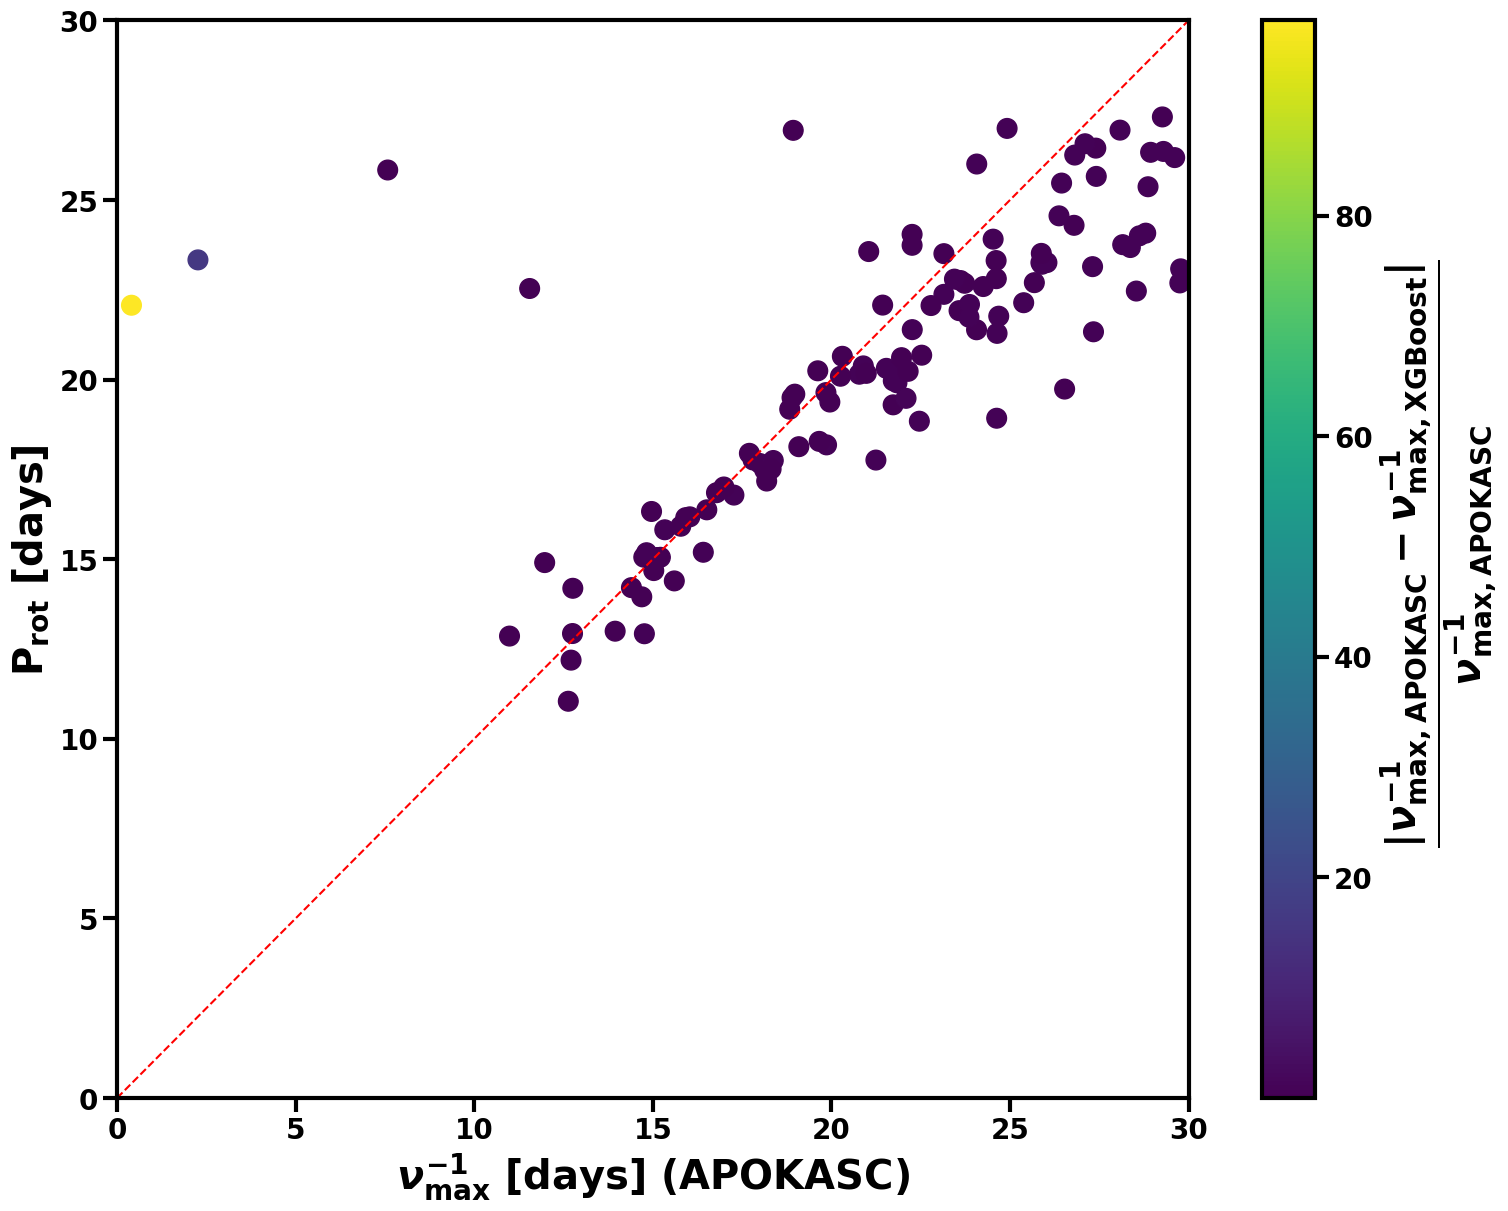

In [141]:
fig, axs = plt.subplots(1, 1, figsize=(15, 12), layout='constrained')
im = axs.scatter(apokasc_per_d, mergedus_apokasc['period'], c=diff, cmap='viridis', norm = normed, s=200, label='', rasterized=True)
cbar = fig.colorbar(im, ax=axs, label=r' $\dfrac{|\nu_{\rm{max, APOKASC}}^{-1} - \nu_{\rm{max, XGBoost}}^{-1}|}{\nu_{\rm{max, APOKASC}}^{-1}}$')#label2)
axs.plot([0, 30], [0, 30], "r--", label="1:1")
axs.set(xlim=[0, 30], ylim=[0, 30], xlabel=r'$\nu_{\rm{max}}^{-1}$ [days] (APOKASC)',  ylabel=r'P$_{\rm{rot}}$ [days]')
plt.show()

# Subgiants

In [142]:
urlemilyleiner = "https://content.cld.iop.org/journals/0004-637X/927/2/222/revision1/apjac53b1t1_mrt.txt"
query_parameters = {"downloadformat": "txt"}
import requests
response = requests.get(urlemilyleiner, params=query_parameters)

with open("leiner.txt", mode="wb") as file:
    file.write(response.content)
subsubgiants = Table.read("leiner.txt", format="ascii.cds").to_pandas().rename(columns={'ID':'edr3_source_id'})


In [ ]:
merged = pd.merge(subgiants, subsubgiants, on='edr3_source_id', how='inner')
#merged #575 matched in full, 574 in sg grouping out opf 46727 total

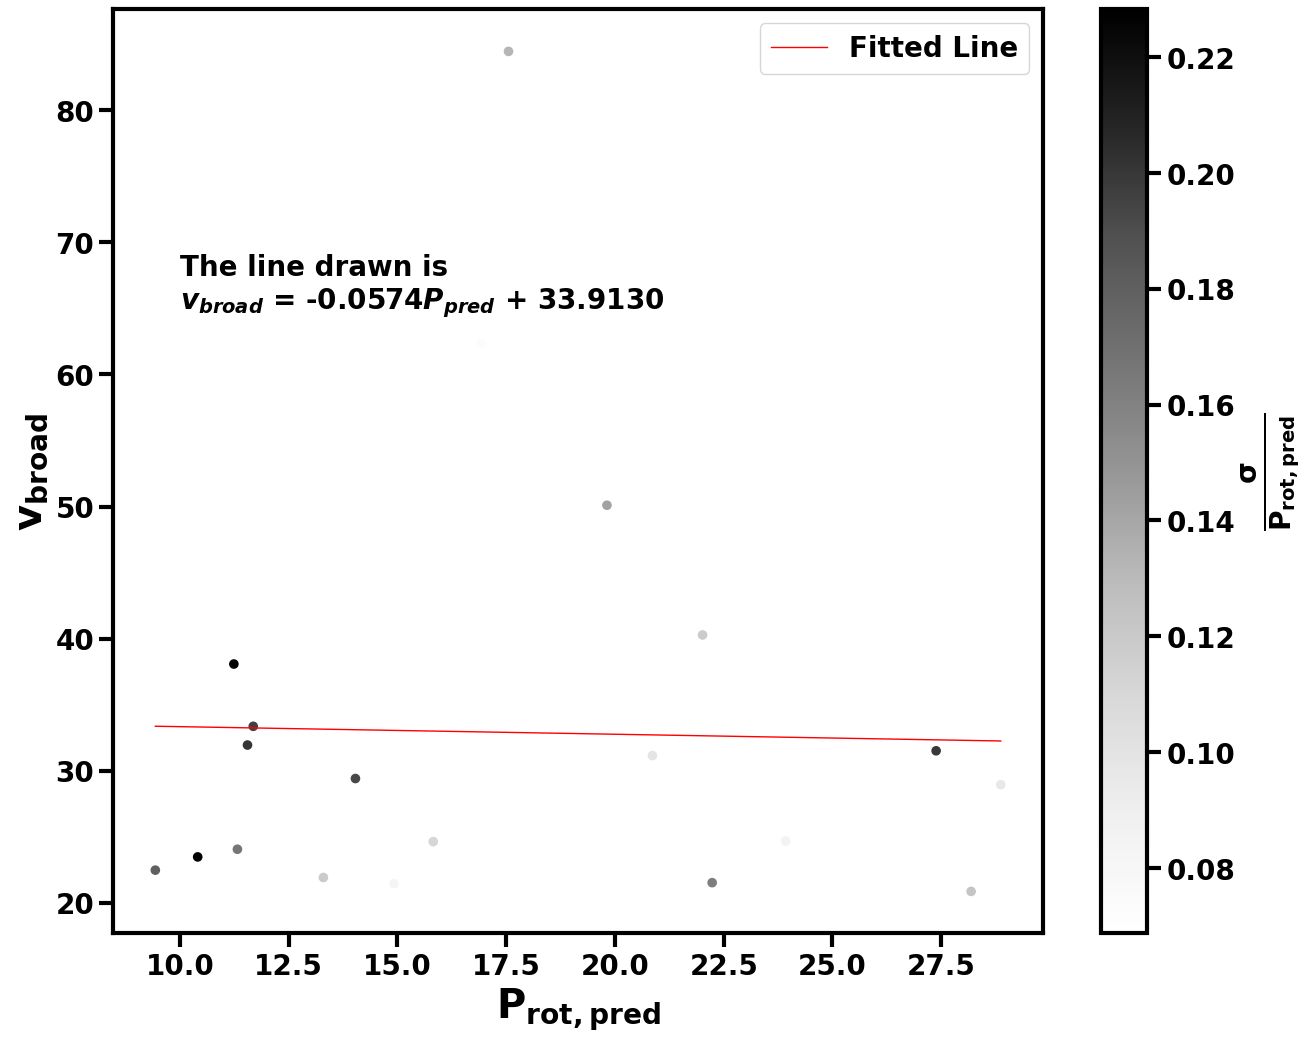

In [166]:
fig, axs = plt.subplots(1, 1, figsize=(15, 12))
cm = plt.colormaps.get_cmap('Greys')

axs.set(xlabel=r'P$_{\rm{rot, pred}}$', ylabel=r'v$_{\rm{broad}}$')
merged.fillna(0, inplace=True)
temp = merged[(merged['vbroad']!=0.0) & (merged['vbroad']>=20)]
xvals = temp['period']
yvals = temp['vbroad']
coefficients = np.polyfit(xvals, yvals, 1)
slope = coefficients[0]
intercept = coefficients[1]
x_fit = np.linspace(min(xvals), max(xvals), 100) # Generate 100 points between min and max x
y_fit = (slope * x_fit) + intercept
axs.plot(x_fit, y_fit, color='red', label='Fitted Line', linewidth=1)
stringer = 'The line drawn is \n$v_{broad}$ = ' + str("%.4f" % slope) + "$P_{pred}$ + " + str("%.4f" % intercept)
normi = colors.Normalize(vmin=np.min(temp['frac']), vmax=np.max(temp['frac']))
im = axs.scatter('period', 'vbroad', c='frac', data=temp, s=35, cmap=cm, label='', norm=normi)
plt.text(10, 65, stringer)
fig.colorbar(im, ax=axs, label=r'$\mathbf{\frac{\sigma}{P_{rot, pred}}}$')#, range=[0, 5]).
plt.legend()
plt.show()

In [162]:
dr2ids = temp['dr2_source_id'].to_list()
len(dr2ids)
Gaia.MAIN_GAIA_TABLE = "gaiadr2.gaia_source" 
query = f"SELECT source_id AS dr2_source_id, radius_percentile_lower, radius_percentile_upper FROM gaiadr2.gaia_source AS gsource WHERE source_id IN ({','.join(map(str, dr2ids))})"
job = Gaia.launch_job(query)
result_table = job.get_results().to_pandas().drop_duplicates(subset='dr2_source_id')

merged5 = pd.merge(temp, result_table, on='dr2_source_id', how='inner')

radii_km = merged5['radius_val']*695700
vbroad_km_days = merged5['vbroad']*86400
numerator = 2*np.pi*radii_km
denominator = vbroad_km_days
pspec = numerator/denominator
periods = merged5['period']
errors_prot = merged5['sigma']
errors_pspec_upper = (merged5['radius_percentile_upper']*695700)/(merged5['vbroad_error']*86400)
errors_pspec_lower = (merged5['radius_percentile_lower']*695700)/(merged5['vbroad_error']*86400)

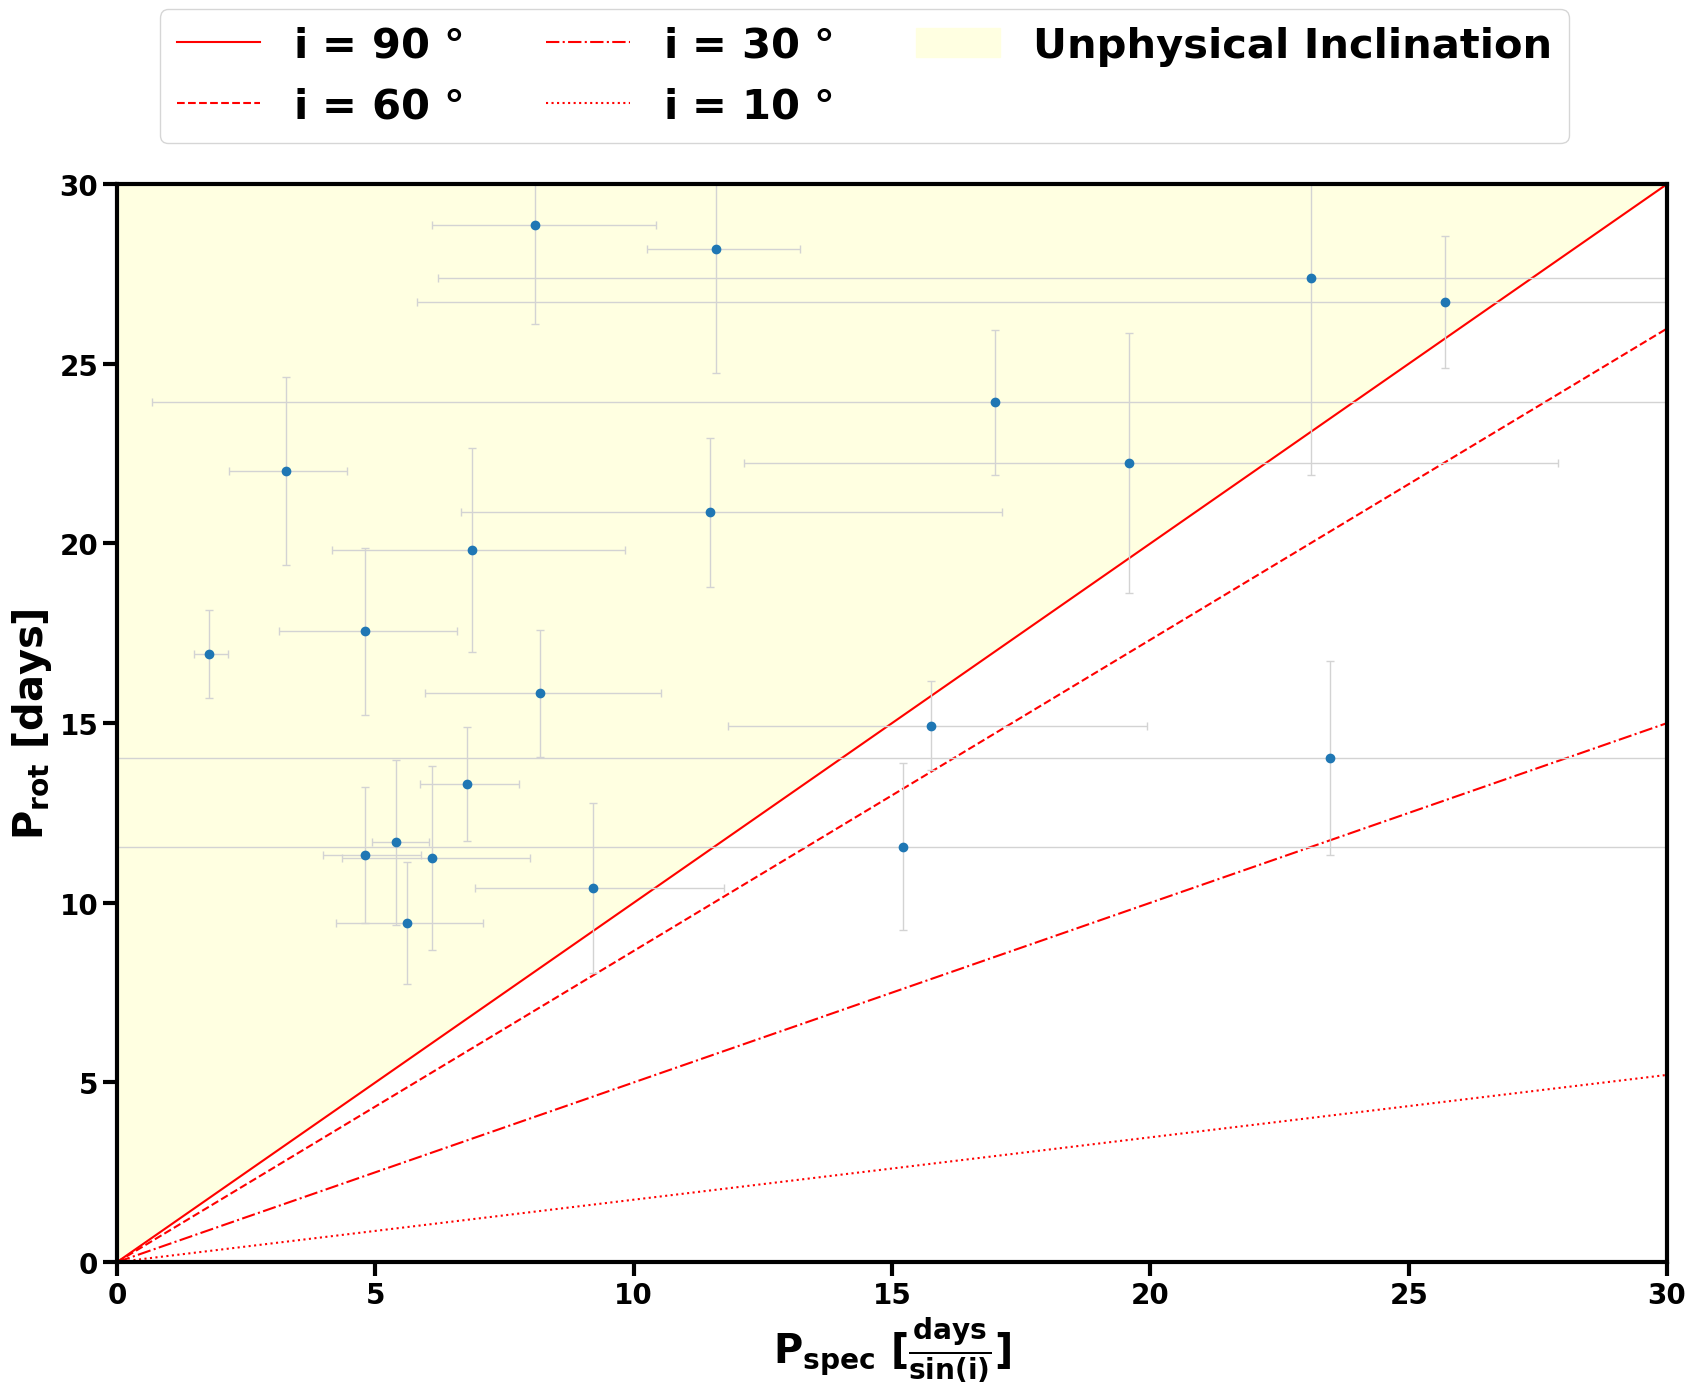

In [163]:
fig, axs = plt.subplots(1, 1, figsize=(20, 14))#, squeeze=True)
axs.set(ylim=[0, 30], xlim=[0, 30], ylabel=r'P$_{\rm{rot}}$ [days]', xlabel=r'P$_{\rm{spec}}$ [$\frac{\rm{days}}{\rm{sin(i)}}$]')
t = axs.plot([0, 30], [0, 30], "r-", label="i = 90 $\degree$")
axs.plot([0, 30], [0, 30*np.sin(60*np.pi*(1/180))], "r--", label="i = 60 $\degree$")
axs.plot([0, 30], [0, 30*np.sin(30*np.pi*(1/180))], "r-.", label="i = 30 $\degree$")
axs.plot([0, 30], [0, 30*np.sin(10*np.pi*(1/180))], "r:", label="i = 10 $\degree$")
axs.fill_between([0, 30], [0, 30], y2=axs.get_ylim()[1], color='lightyellow', alpha=0.95, label='Unphysical Inclination')
im0 = axs.errorbar(pspec, periods, yerr=errors_prot, xerr=(errors_pspec_lower, errors_pspec_upper), fmt='o',
             ecolor='lightgray', elinewidth=1, capsize=3)
axs.legend(loc='center right', ncols=3, bbox_to_anchor=(0.95, 1.1), fontsize=30)

Text(0.5, 1.0, 'Leiner et al. (Subsubgiants)')

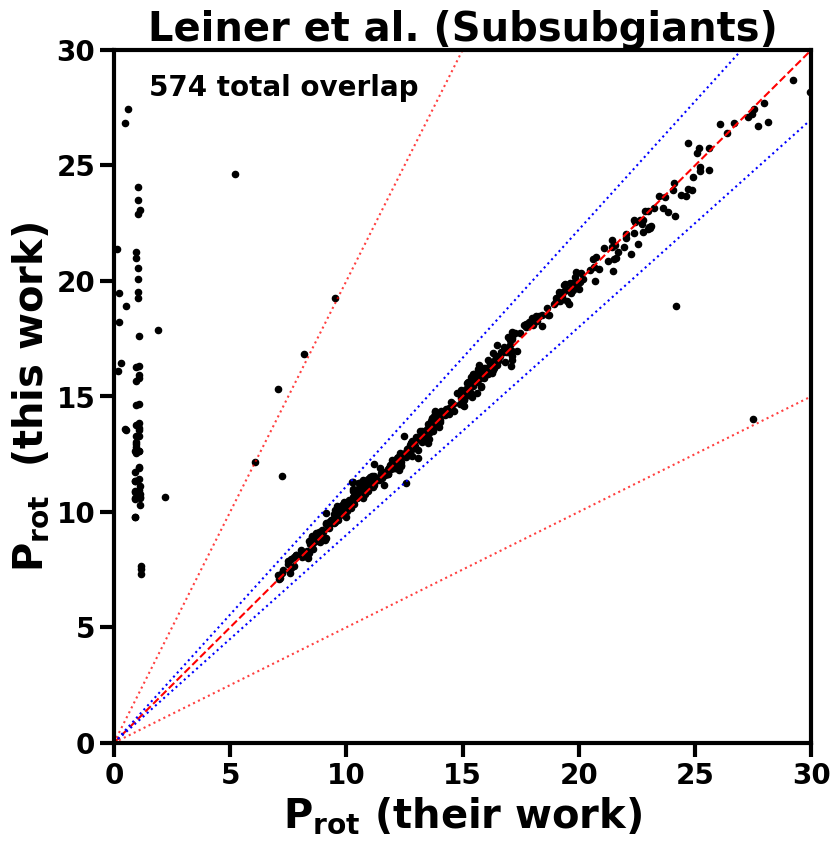

In [167]:
fig, axs = plt.subplots(1, 1, figsize=(9, 9))

axs.plot([0, 30], [0, 30], "r--", label="1:1")
axs.plot([0, 30*0.9], [0, 30], "b:",  label="90th percentile")
axs.plot([0, 30], [0, 30*0.9], "b:")
axs.plot([0, 30], [0, 30*2], "r:",  label="2:1 and 1:2 aliases", alpha=0.75)
axs.plot([0, 30], [0, 30*0.5], "r:", alpha=0.75)

axs.set_xlim(0, 30)
axs.set_ylim(0, 30)
axs.set_xlabel('P$\\bf _{rot}$ (their work)', weight='bold')
axs.set_ylabel('P$\\bf _{rot}$  (this work)', weight='bold')
axs.text(1.5, 28, f"{len(merged)} total overlap", fontweight='bold')
axs.scatter('PVSX', 'period' , data=merged, c='k', s=20, label='', rasterized=True)
axs.set_title('Leiner et al. (Subsubgiants)', weight="bold")

In [168]:
rscvn = subsubgiants[subsubgiants['Class']=='RS']
ssgs = subsubgiants[subsubgiants['Class']=='SSG']
mergedssgs = pd.merge(subgiants, ssgs, on='edr3_source_id', how='inner')
mergedrscvs = pd.merge(subgiants, rscvn, on='edr3_source_id', how='inner')

ssgsonlyleiner = ssgs[~ssgs['edr3_source_id'].isin(mergedssgs['edr3_source_id'])]
rscvnonlyleiner = rscvn[~rscvn['edr3_source_id'].isin(mergedrscvs['edr3_source_id'])]


In [169]:
rscvnonlyleiner.columns

Index(['edr3_source_id', 'VSX', 'TIC', 'RAdeg', 'DEdeg', 'D', 'Gmag',
       '(BP-RP)', 'RUWE', 'chi2', 'NAL', 'PVSX', 'PTess', 'Amp', 'NSec', 'AV',
       'Class'],
      dtype='object')

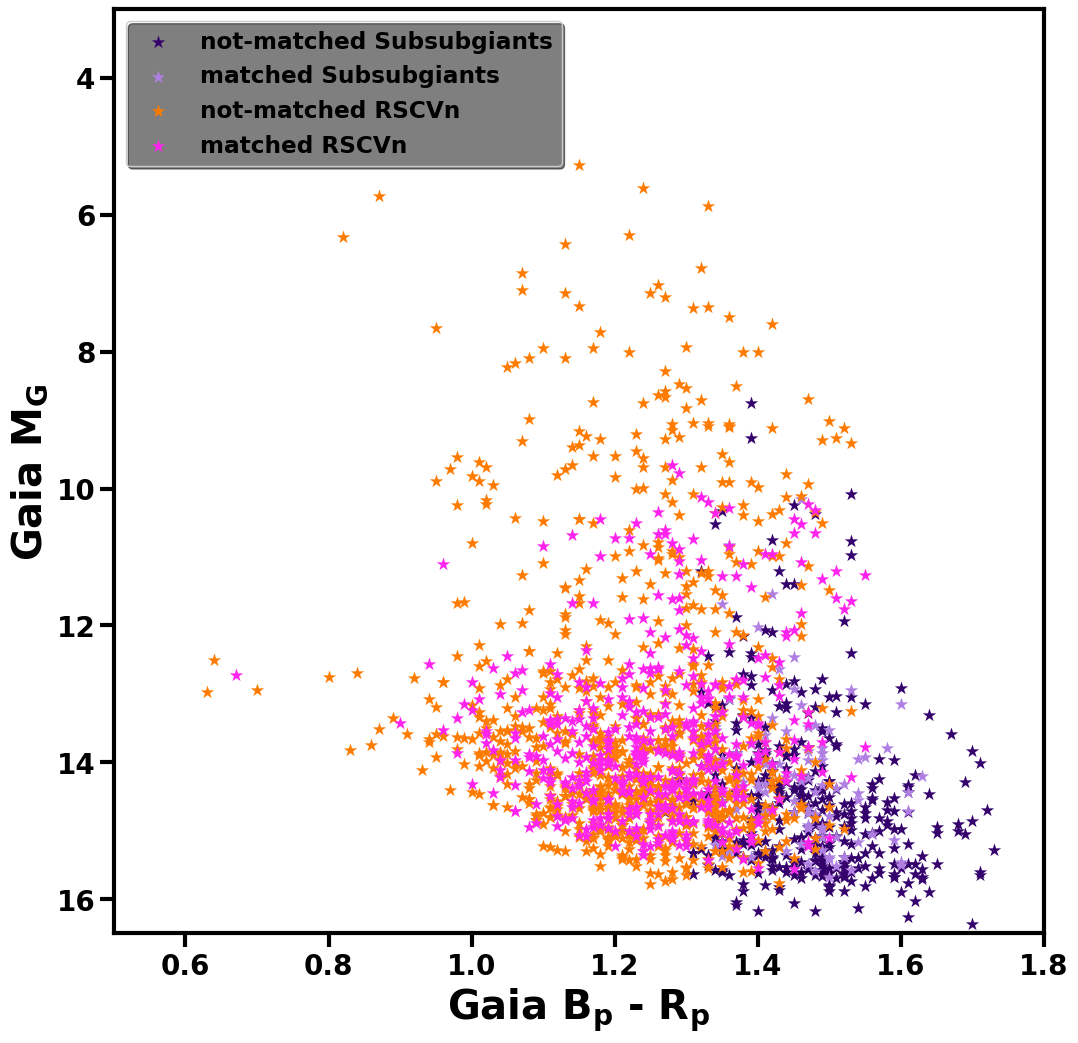

In [170]:
fig, axs = plt.subplots(1, 1, figsize=(12, 12))

axs.set_xlim(0.5, 1.8)
axs.set_ylim(16.5, 3)
axs.set_xlabel(f'Gaia $\\bf B_p$ - $\\bf R_p$', weight='bold')
axs.set_ylabel(f'Gaia $\\bf M_G$', weight='bold')
#axs.plot([0.6, 0.6], [15, -17], c="#000000", label="Kraft Break", rasterized=True, linewidth=2)
imhot = axs.scatter('(BP-RP)', 'Gmag', c="#34006C", s=100, marker="*", data=ssgsonlyleiner, linewidths=0.01, label='not-matched Subsubgiants', rasterized=True)
imsub = axs.scatter('(BP-RP)', 'Gmag', c="#AF7FE2", s=100, marker="*", data=mergedssgs,linewidths=0.01, label='matched Subsubgiants', rasterized=True)

imms = axs.scatter('(BP-RP)', 'Gmag', c="#FE7B00", s=100, marker="*", data=rscvnonlyleiner, linewidths=0.01, label='not-matched RSCVn', rasterized=True)
imosc = axs.scatter('(BP-RP)', 'Gmag', c="#FF24ED", s=100, marker="*", data=mergedrscvs, linewidths=0.01, label='matched RSCVn', rasterized=True)

plt.legend(loc='upper left', shadow=True, fontsize='small')
#plt.savefig('hrsubpopulations.pdf',  dpi=300)
plt.show()